In [1]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
# LOAD DATA
df = pd.read_csv("D:/customer-segmentation-unsupervised/data/processed/rfm_data.csv")

print("Data Loaded Successfully ")
df.head()

Data Loaded Successfully 


,user_id,Recency,Frequency,Monetary,Views,Carts,Purchase_Ratio,Avg_Spend
0,356520186,0,1,33.45,5.0,0.0,0.166667,16.725000
1,397023870,0,1,244.28,3.0,0.0,0.250000,122.140000
2,486999716,0,1,242.72,3.0,0.0,0.250000,121.360000
3,509881222,0,1,200.52,55.0,0.0,0.017857,100.260000
4,512364896,0,5,708.01,16.0,3.0,0.294118,118.001667


In [3]:
# PREPARE DATA
# Save user_id separately
if "user_id" in df.columns:
    user_ids = df["user_id"]

# Remove user_id for clustering
df_model = df.drop(columns=["user_id"], errors="ignore")

# Fill missing values
df_model = df_model.fillna(0)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

print("Data Prepared ")

Data Prepared 


In [5]:
# APPLY KMEANS (BEST K FROM PREVIOUS STEP)
k = 4  # Based on Elbow + Silhouette

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("Clustering Applied ")

Clustering Applied 


In [6]:
# APPLY PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("PCA Applied ")

PCA Applied 


In [7]:
# EXPLAINED VARIANCE
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:", explained_variance)
print("Total Variance Explained:", sum(explained_variance))

Explained Variance Ratio: [0.37545263 0.26252601]
Total Variance Explained: 0.6379786396540524


In [8]:
# CREATE PCA DATAFRAME
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clusters
})

pca_df.head()

,PC1,PC2,Cluster
0,-1.175081,0.104225,1
1,-0.573534,-0.462322,2
2,-0.577284,-0.461763,2
3,-0.786015,4.066747,1
4,2.663030,1.556536,0


In [9]:
# SAVE PCA DATA
output_folder = "D:/customer-segmentation-unsupervised/results/pca_outputs"
os.makedirs(output_folder, exist_ok=True)

pca_df.to_csv(f"{output_folder}/pca_data.csv", index=False)

print("PCA Data Saved ")

PCA Data Saved 


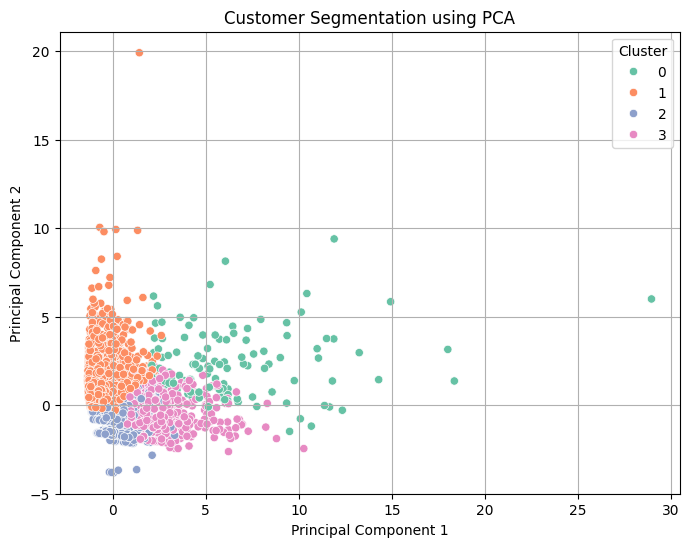

In [10]:
# PCA VISUALIZATION
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    data=pca_df
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")
plt.grid()

plt.show()

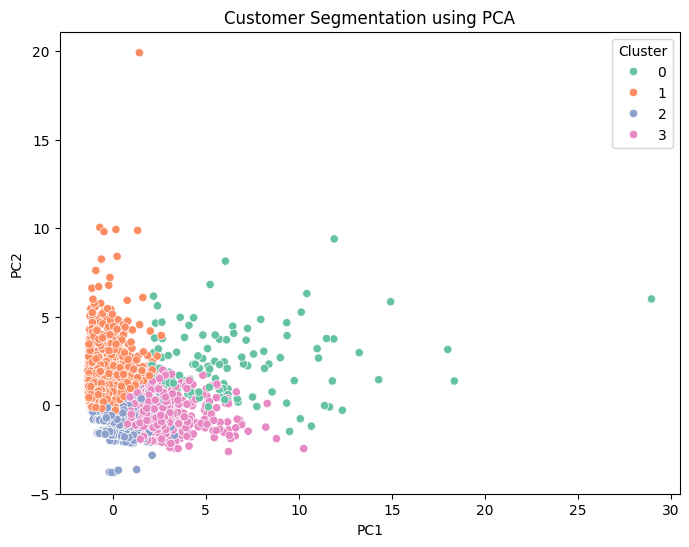

PCA Graph Saved 


In [12]:
# SAVE PCA GRAPH
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    data=pca_df
)

plt.title("Customer Segmentation using PCA")

plt.savefig(f"{output_folder}/pca_clusters.png")

plt.show()

print("PCA Graph Saved ")

In [13]:
# CLUSTER SUMMARY
cluster_summary = df.groupby("Cluster").mean()

print(cluster_summary)

              user_id  Recency  Frequency     Monetary      Views     Carts  \
Cluster                                                                       
0        5.405820e+08      0.0   6.170732  2395.854959  21.560976  5.650407   
1        5.364108e+08      0.0   1.163047   194.340705  12.787850  0.557444   
2        5.396274e+08      0.0   1.215309   224.727528   2.528339  0.529316   
3        5.377737e+08      0.0   1.383710  1271.439971   5.186457  0.838077   

         Purchase_Ratio   Avg_Spend  
Cluster                              
0              0.332594  338.224026  
1              0.120383   88.499986  
2              0.363339  100.288703  
3              0.278163  534.991720  
